In [2]:
!pip install matplotlib seaborn scikit-learn

In [3]:
# 📦 Importação das bibliotecas necessárias
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 📦 Importa a função para carregar o dataset
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# 🔽 Carrega o dataset Iris
iris = load_iris()

# 🧾 Converte para um DataFrame do pandas
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Adiciona a coluna alvo (espécie da flor)
df["target"] = iris.target
df["target_name"] = df["target"].apply(lambda x: iris.target_names[x])

# 👀 Exibe as 5 primeiras linhas
print("Dataset Iris carregado com sucesso!")
df.head()

Dataset Iris carregado com sucesso!


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


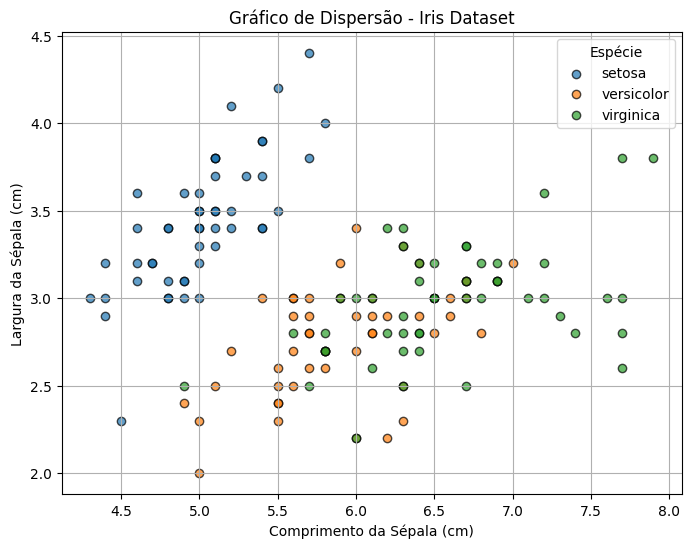

In [5]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = [iris.target_names[t] for t in iris.target]

# 🎨 Cria um gráfico de dispersão
plt.figure(figsize=(8, 6))
for species in df["species"].unique():
    subset = df[df["species"] == species]
    plt.scatter(
        subset["sepal length (cm)"],
        subset["sepal width (cm)"],
        label=species,
        alpha=0.7,
        edgecolors="k"
    )

# 🧾 Configurações do gráfico
plt.title("Gráfico de Dispersão - Iris Dataset")
plt.xlabel("Comprimento da Sépala (cm)")
plt.ylabel("Largura da Sépala (cm)")
plt.legend(title="Espécie")
plt.grid(True)
plt.show()


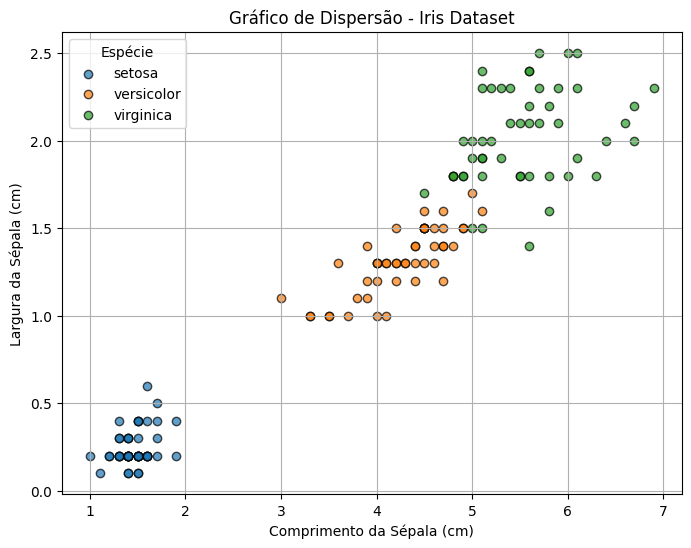

In [6]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = [iris.target_names[t] for t in iris.target]

# 🎨 Cria um gráfico de dispersão
plt.figure(figsize=(8, 6))
for species in df["species"].unique():
    subset = df[df["species"] == species]
    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=species,
        alpha=0.7,
        edgecolors="k"
    )

# 🧾 Configurações do gráfico
plt.title("Gráfico de Dispersão - Iris Dataset")
plt.xlabel("Comprimento da Sépala (cm)")
plt.ylabel("Largura da Sépala (cm)")
plt.legend(title="Espécie")
plt.grid(True)
plt.show()


Tamanho do conjunto de treino: 120 amostras
Tamanho do conjunto de validação: 30 amostras

Acurácia no conjunto de validação: 90.00%

Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



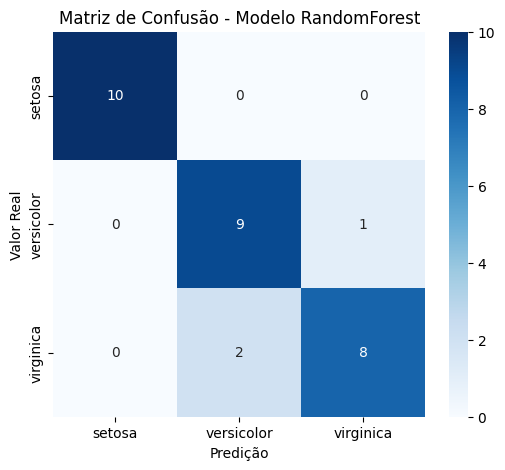

In [7]:
iris = load_iris()
X = iris.data              # features (características)
y = iris.target            # target (rótulos das classes)
target_names = iris.target_names

# ✂️ Divide o dataset em treino (80%) e validação (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de validação: {len(X_val)} amostras")

# 🌳 Cria e treina o modelo de classificação
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 🔍 Faz previsões no conjunto de validação
y_pred = model.predict(X_val)

# 📈 Avalia o desempenho
acc = accuracy_score(y_val, y_pred)
print(f"\nAcurácia no conjunto de validação: {acc:.2%}\n")

print("Relatório de Classificação:")
print(classification_report(y_val, y_pred, target_names=target_names))

# 🧩 Matriz de Confusão
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Matriz de Confusão - Modelo RandomForest")
plt.xlabel("Predição")
plt.ylabel("Valor Real")
plt.show()


In [8]:
def prever_especie(valores):
    """
    Recebe um array ou lista de valores no formato:
    [comprimento_sépala, largura_sépala, comprimento_pétala, largura_pétala]
    e retorna o nome da espécie prevista.
    """
    valores = np.array(valores).reshape(1, -1)  # garante formato 2D
    pred = model.predict(valores)
    especie = iris.target_names[pred[0]]
    return especie

In [9]:
exemplo = [5.1, 3.5, 1.4, 0.2]  # valores típicos da espécie Setosa
resultado = prever_especie(exemplo)
resultado

np.str_('setosa')

In [10]:
import mlflow

mlflow.set_experiment("MLflow Quickstart")

/home/teru/.venv/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///home/teru/aula%20monitoramento/mlruns/245880388660663795', creation_time=1762983343080, experiment_id='245880388660663795', last_update_time=1762983343080, lifecycle_stage='active', name='MLflow Quickstart', tags={}>

In [11]:
import pandas as pd
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

import mlflow
import mlflow.sklearn
from mlflow.entities import Dataset

mlflow.set_experiment(experiment_name="642323944495184780")

# Helper function to compute metrics
def compute_metrics(actual, predicted):
    rmse = mean_squared_error(actual, predicted) 
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    return rmse, mae, r2

# Load Iris dataset and prepare the DataFrame
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['quality'] = (iris.target == 2).astype(int)  # Create a binary target for simplicity

# Split into training and testing datasets
train_df, test_df = train_test_split(iris_df, test_size=0.2, random_state=42)

# Start a run to represent the training job
with mlflow.start_run() as training_run:
    # Load the training dataset with MLflow. We will link training metrics to this dataset.
    train_dataset: Dataset = mlflow.data.from_pandas(train_df, name="train")
    train_x = train_dataset.df.drop(["quality"], axis=1)
    train_y = train_dataset.df[["quality"]]

    # Fit a model to the training dataset
    lr = ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=42)
    lr.fit(train_x, train_y)

    # Log the model, specifying its ElasticNet parameters (alpha, l1_ratio)
    # As a new feature, the LoggedModel entity is linked to its name and params
    model_info = mlflow.sklearn.log_model(
        sk_model=lr,
        name="elasticnet",
        params={
            "alpha": 0.5,
            "l1_ratio": 0.5,
        },
        input_example = train_x
    )

    # Inspect the LoggedModel and its properties
    logged_model = mlflow.get_logged_model(model_info.model_id)
    print(logged_model.model_id, logged_model.params)

    # Evaluate the model on the training dataset and log metrics
    # These metrics are now linked to the LoggedModel entity
    predictions = lr.predict(train_x)
    (rmse, mae, r2) = compute_metrics(train_y, predictions)
    mlflow.log_metrics(
        metrics={
            "rmse": rmse,
            "r2": r2,
            "mae": mae,
        },
        model_id=logged_model.model_id,
        dataset=train_dataset
    )

    # Inspect the LoggedModel, now with metrics
    logged_model = mlflow.get_logged_model(model_info.model_id)
    print(logged_model.model_id, logged_model.metrics)

m-87bc903e0ae849fc9d7e6d049c00f187 {'alpha': '0.5', 'l1_ratio': '0.5'}
m-87bc903e0ae849fc9d7e6d049c00f187 [<Metric: dataset_digest='d95ce242', dataset_name='train', key='rmse', model_id='m-87bc903e0ae849fc9d7e6d049c00f187', run_id='b709aafb387d404fa9cdfb2611e6f0f6', step=0, timestamp=1762985471415, value=0.1326400936461997>, <Metric: dataset_digest='d95ce242', dataset_name='train', key='mae', model_id='m-87bc903e0ae849fc9d7e6d049c00f187', run_id='b709aafb387d404fa9cdfb2611e6f0f6', step=0, timestamp=1762985471415, value=0.3209158276037644>, <Metric: dataset_digest='d95ce242', dataset_name='train', key='r2', model_id='m-87bc903e0ae849fc9d7e6d049c00f187', run_id='b709aafb387d404fa9cdfb2611e6f0f6', step=0, timestamp=1762985471415, value=0.3953727924959558>]


/home/teru/.venv/lib/python3.11/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [12]:
mlflow.set_experiment("my-first-experiment")
# Print connection information
print(f"MLflow Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Active Experiment: {mlflow.get_experiment_by_name('my-first-experiment')}")

# Test logging
with mlflow.start_run():
    mlflow.log_param("test_param", "test_value")
    print("✓ Successfully connected to MLflow!")

MLflow Tracking URI: file:///home/teru/aula_monitoramento/mlruns
Active Experiment: <Experiment: artifact_location='file:///home/teru/aula%20monitoramento/mlruns/879391292841160764', creation_time=1762984984214, experiment_id='879391292841160764', last_update_time=1762984984214, lifecycle_stage='active', name='my-first-experiment', tags={}>
✓ Successfully connected to MLflow!


In [13]:
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import mlflow

mlflow.set_experiment("MLflow Quickstart")
# Load the Iris dataset
X, y = datasets.load_iris(return_X_y=True)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the model hyperparameters
params = {
    "solver": "lbfgs",
    "max_iter": 1000,
    "multi_class": "auto",
    "random_state": 8888,
}

In [14]:
import mlflow

# Enable autologging for scikit-learn
mlflow.sklearn.autolog()

# Just train the model normally
lr = LogisticRegression(**params)
lr.fit(X_train, y_train)

2025/11/12 19:11:11 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f62dfb0cbaad4214bff3d095a3c6380c', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
/home/teru/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,8888
,solver,'lbfgs'
,max_iter,1000
,multi_class,'auto'


In [15]:
# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Train the model
    lr = LogisticRegression(**params)
    lr.fit(X_train, y_train)

    # Log the model
    mlflow.sklearn.log_model(sk_model=lr, name="iris_model")

    # Predict on the test set, compute and log the loss metric
    y_pred = lr.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    # Optional: Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "Basic LR model for iris data")

/home/teru/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2025/11/12 19:11:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [16]:
# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Train the model
    lr = LogisticRegression(**params)
    lr.fit(X_train, y_train)

    # Log the model
    mlflow.sklearn.log_model(sk_model=lr)# , name="iris_model")

    # Predict on the test set, compute and log the loss metric
    y_pred = lr.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    # Optional: Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "Basic LR model for iris data")

/home/teru/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2025/11/12 19:11:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [17]:
mlflow.sklearn.autolog()

In [18]:
# Load the model back for predictions as a generic Python Function model
mlflow.sklearn.load_model(model_info.model_uri)

predictions = loaded_model.predict(X_test)

iris_feature_names = datasets.load_iris().feature_names

result = pd.DataFrame(X_test, columns=iris_feature_names)
result["actual_class"] = y_test
result["predicted_class"] = predictions

result[:4]

NameError: name 'loaded_model' is not defined

In [ ]:
https://mlflow.org/docs/latest/ml/tracking/quickstart/

In [ ]:
import pandas as pd
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import mlflow
from mlflow.models import infer_signature
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")
# Load the Iris dataset
X, y = datasets.load_iris(return_X_y=True)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model hyperparameters
params = {"solver": "lbfgs", "max_iter": 1000, "multi_class": "auto", "random_state": 8888}

# Train the model
lr = LogisticRegression(**params)
lr.fit(X_train, y_train)

# Predict on the test set
y_pred = lr.predict(X_test)

# Calculate accuracy as a target loss metric
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
mlflow.set_experiment("MLflow Quickstart")

In [ ]:
# Start an MLflow run
with mlflow.start_run():
  # Log the hyperparameters
  mlflow.log_params(params)

  # Log the loss metric
  mlflow.log_metric("accuracy", accuracy)

  # Set a tag that we can use to remind ourselves what this run was for
  mlflow.set_tag("Training Info", "Basic LR model for iris data")

  # Infer the model signature
  signature = infer_signature(X_train, lr.predict(X_train))

  # Log the model
  model_info = mlflow.sklearn.log_model(
      sk_model=lr,
      name="iris_model",
      signature=signature,
      input_example=X_train,
      registered_model_name="tracking-quickstart",
  )

In [ ]:
loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)

In [ ]:
predictions = loaded_model.predict(X_test)

iris_feature_names = datasets.load_iris().feature_names

# Convert X_test validation feature data to a Pandas DataFrame
result = pd.DataFrame(X_test, columns=iris_feature_names)

# Add the actual classes to the DataFrame
result["actual_class"] = y_test

# Add the model predictions to the DataFrame
result["predicted_class"] = predictions

result[:4]